In [1]:
# 日本語対応のモジュールをインストールする(その1)
!pip install japanize-matplotlib
# 日本語対応のモジュールをインストールする(その2)
!apt-get install -y fonts-ipafont-gothic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 31.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=e80b6848b64e5c5a575df89f3c7c638f1cb1ba87c5ab81f01645c5451890c6e2
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-ipafont-mincho
The following NEW packages will be installed:
  fonts-ipafont-gothic fonts-ipafont-mincho
0 upgraded, 2 newly installed, 0 to remove and 3 not upgraded.
Need to get 8,237 kB of archives.
After this operation, 28.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-ipafont-gothic all 00303-21ubuntu1 [3,513 kB]
Get:2 http://ar

In [2]:
# 各ライブラリーをインポートする
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import japanize_matplotlib # noqa: F401
except Exception:
    pass
plt.rcParams["axes.unicode_minus"] = False
RNG = np.random.default_rng(20260709)

In [3]:
# データ読み込み
LISTINGS_URL = ("https://data.insideairbnb.com/japan/kant%C5%8D/tokyo/"
"2023-06-29/visualisations/listings.csv")
FEAT_NUM = ["latitude", "longitude", "minimum_nights", "number_of_reviews",
"reviews_per_month", "availability_365", "calculated_host_listings_count"]
FEAT_CAT = ["neighbourhood", "room_type"]
def load_listings():
    try:
        df = pd.read_csv(LISTINGS_URL)
        df["price"] = (df["price"].astype(str).str.replace(r"[ \$,]", "", regex=True)
        .replace("", np.nan).astype(float))
        df = df [FEAT_NUM + FEAT_CAT + ["price"]].dropna (subset=["price", "room_type", "neighbourhood"])
        df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
        df = df[(df["price"] > 0) & (df ["price"] < df["price"].quantile(0.99))]
        print(f"[実データ] listings を読み込み: {len(df):,}件")
        return df.reset_index(drop=True), True
    except Exception as e:
        print(f" [フォールバック] 実データを取得できません({type(e).__name__})。合成データで続行。")
        return synthesize_listings(), False

def synthesize_listings(n=15000):
    wards = ["Shinjuku", "Shibuya", "Taito", "Sumida", "Toshima", "Nakano", "Setagaya", "Ota", "Katsushika", "Arakawa"]
    wp = dict(zip (wards, [1.0,1.05,0.85,0.75,0.7,0.6,0.55,0.45,0.35,0.4]))
    w = np.array([2.2,2.0,1.6,1.3,1.1,0.9,0.9,0.8,0.7,0.7]); w = w/w.sum()
    ward = RNG.choice(wards, n, p=w)
    rooms = ["Entire home/apt", "Private room", "Hotel room", "Shared room"]
    re_ = {"Entire home/apt": 1.0, "Private room": 0.45, "Hotel room": 0.7, "Shared room": 0.25}
    room = RNG.choice(rooms, n, p=[0.62,0.30,0.05,0.03])
    mn = np.clip(RNG.lognormal(0.7,0.8,n).astype(int),1,365)
    nrev = RNG.poisson(np.clip(RNG.lognormal(2.2,1.1,n),0, None)).astype(int)
    rpm = np.round(np.clip(RNG.gamma(1.5,0.7,n), 0, None), 2)
    av = np.clip((RNG.beta(1.4,1.6,n)*365).astype(int),0,365)
    hl = np.clip(RNG.lognormal(0.6,1.0,n).astype (int), 1, None)
    lat = 35.68 + RNG.normal(0,0.045,n); lon = 139.75 + RNG.normal(0,0.055,n)
    wpar = np.array([wp[x] for x in ward]); ent = (room=="Entire home/apt"); shr = (room=="Shared room")
    #木が有利になる「交互作用・非単調・しきい値」を含む価格モデル
    price = (3600*np.array([re_[r] for r in room])*(0.6+0.8*wpar)
    *(1+0.9*ent*(wpar>0.8))
    *( 0.75+0.5*np.exp(-((av-180)**2)/(2*70**2)))
    *np.where(mn<=3,1.15,np.where(mn>=30,0.8,1.0))
    *(1+0.5*(nrev>20)*ent-0.3*(nrev>20)*shr)
    *(1+RNG.normal(0,0.25,n)))
    # 交互作用:一棟貸し×中心区
    # 非単調:稼働率の山
    # しきい値: 最低宿泊数
    # 交互作用:レビュー×部屋
    price = np.clip(price, 1500, None).astype(int)
    return pd.DataFrame({"neighbourhood": ward, "room_type":room, "latitude":lat.round(5),
    "longitude":lon.round(5),"minimum_nights":mn, "number_of_reviews":nrev,
    "reviews_per_month": rpm, "availability_365":av,
    "calculated_host_listings_count":hl, "price": price})

df, IS_REAL = load_listings()
#目的変数:高価格帯か(中央値以上の二値分類)。price は特徴量から除外。
thr = int(df["price"].median())
y = (df["price"] >= thr).astype(int).values
X = df [FEAT_NUM + FEAT_CAT].copy()
print(f"目的変数=高価格帯か(中央値 {thr}) 正例率 {y.mean():.3f} 特徴量 {X.shape[1]}個\n")

from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size =0.25, random_state =0, stratify=y)

# 前処理の部品
pre_scaled = ColumnTransformer ([("num", StandardScaler(), FEAT_NUM),
("cat", OneHotEncoder (handle_unknown="ignore"), FEAT_CAT)])

pre_ord = ColumnTransformer([("cat", OrdinalEncoder (handle_unknown="use_encoded_value", unknown_value =-1), FEAT_CAT)],
remainder="passthrough") # 先頭2列=カテゴリ、残り数値

def make_logreg(): return Pipeline([("pre", pre_scaled), ("clf", LogisticRegression (max_iter=1000))])
def make_mlp_raw(): return Pipeline([("pre", pre_ord), ("clf", MLPClassifier((64,32), max_iter =200,
random_state=0))])
def make_mlp_ok(hidden=(64,32), max_iter =300):
    return Pipeline ([("pre", pre_scaled), ("clf", MLPClassifier(hidden, max_iter=max_iter, random_state=0))])
def make_gbdt(): return Pipeline ([("pre", pre_ord), ("clf", HistGradientBoostingClassifier (categorical_features =[0,1],
random_state=0))])

def evaluate(name, pipe, Xa=Xtr, ya=ytr):
    t = time.time(); pipe.fit(Xa, ya); ft = time.time()-t
    pr = pipe.predict_proba(Xte)  [:, 1]; p = pipe.predict(Xte)
    auc = roc_auc_score(yte, pr)
    acc = accuracy_score(yte, p);
    print(f"{name:30s} 正解率={acc:.3f} AUC={auc:.3f} 学習時間={ft:5.2f}s")
    return {"name": name, "acc": acc, "auc": auc, "fit": ft}

def run (name, pipe):
    t = time.time(); pipe.fit(Xtr, ytr); ft = time.time() - t
    p = pipe.predict(Xte); pr = pipe.predict_proba(Xte) [:, 1]
    acc = accuracy_score (yte, p); auc = roc_auc_score(yte, pr)
    print(f"{name:32s} 正解率={acc:.3f} AUC={auc:.3f} 学習時間={ft:5.2f}s")
    return {"name": name, "acc": acc, "auc": auc, "fit": ft}

results = []
print("=== 比較 ===")
# ステップ1:MLP(スケーリングなし) - NN特有の落とし穴を体感
pre_raw = ColumnTransformer (
[("cat", OrdinalEncoder (handle_unknown="use_encoded_value", unknown_value =-1), FEAT_CAT)],
remainder="passthrough")
mlp_raw = Pipeline ([("pre", pre_raw),
("clf", MLPClassifier (hidden_layer_sizes =(64,32), max_iter =200, random_state =0))])
results.append(run ("MLP(スケーリングなし)", mlp_raw))

# ステップ 2: MLP(標準化+One-Hot) - 正しい前処理
pre_scaled = ColumnTransformer([
("num", StandardScaler(), FEAT_NUM),
("cat", OneHotEncoder (handle_unknown="ignore"), FEAT_CAT)])
mlp_ok = Pipeline([("pre", pre_scaled),
("clf", MLPClassifier (hidden_layer_sizes =(64,32), max_iter =300, random_state =0))])
results.append(run("MLP(標準化+One-Hot)", mlp_ok))

# ステップ3:勾配ブースティング(最小前処理・カテゴリはネイティブ対応)
pre_gb = ColumnTransformer(
[("cat", OrdinalEncoder (handle_unknown="use_encoded_value", unknown_value =-1), FEAT_CAT)],
remainder="passthrough")
gb = Pipeline ([("pre", pre_gb),
("clf", HistGradientBoostingClassifier (categorical_features =[0,1], random_state =0))])
results.append(run("勾配ブースティング(最小前処理)",gb))

[実データ] listings を読み込み: 11,055件
目的変数=高価格帯か(中央値 14286) 正例率 0.502 特徴量 9個

=== 比較 ===
MLP(スケーリングなし)                    正解率=0.583 AUC=0.654 学習時間= 5.40s


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP(標準化+One-Hot)                 正解率=0.757 AUC=0.831 学習時間=24.82s
勾配ブースティング(最小前処理)                 正解率=0.783 AUC=0.859 学習時間= 0.55s


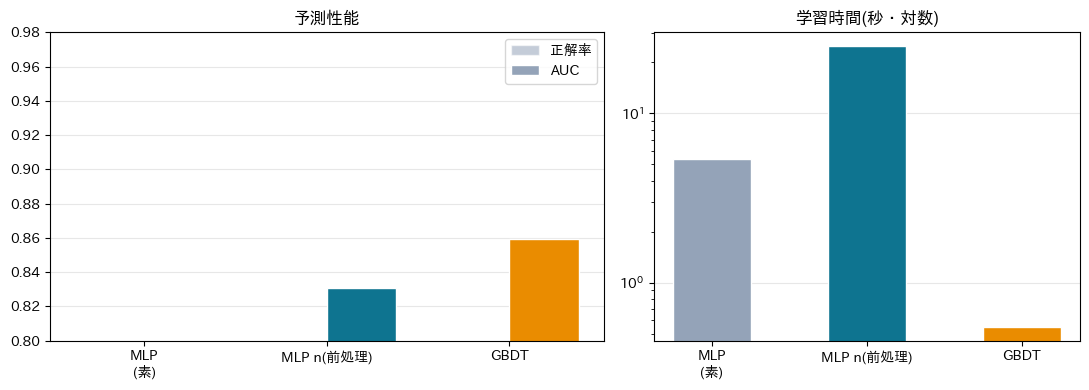

In [5]:
labels = ["MLP\n(素)", "MLP n(前処理)", "GBDT"]
acc = [r["acc"] for r in results]; auc = [r["auc"] for r in results]; fit = [r["fit"] for r in results]
colors = ["#94A3B8", "#0E7490", "#EA8C00"]
fig, (a1, a2) = plt.subplots (1, 2, figsize =(11,4), gridspec_kw={"width_ratios": [1.3, 1]})
x = np.arange(3); w=0.38
a1.bar(x - w/2, acc, w, label="正解率",color=colors, alpha =0.55, edgecolor="white")
a1.bar(x + w/2, auc, w, label="AUC", color=colors, edgecolor="white")
a1.set_xticks(x); a1.set_xticklabels(labels); a1.set_ylim(0.8, 0.98)
a1.set_title("予測性能"); a1.legend(); a1.grid(axis="y", alpha =.3); a1.set_axisbelow (True)
a2.bar(x, fit, 0.5, color=colors, edgecolor="white"); a2.set_yscale("log")
a2.set_xticks(x); a2.set_xticklabels (labels); a2.set_title("学習時間(秒・対数)")
a2.grid(axis="y", alpha=.3); a2.set_axisbelow (True)
plt.tight_layout(); plt.show()

ロジスティック回帰(第7回)                 正解率=0.607 AUC=0.658 学習時間= 0.67s
MLP(スケーリングなし)                  正解率=0.583 AUC=0.654 学習時間= 8.97s


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP(標準化+One-Hot)               正解率=0.757 AUC=0.831 学習時間=21.69s
勾配ブースティング (GBDT)               正解率=0.783 AUC=0.859 学習時間= 0.42s


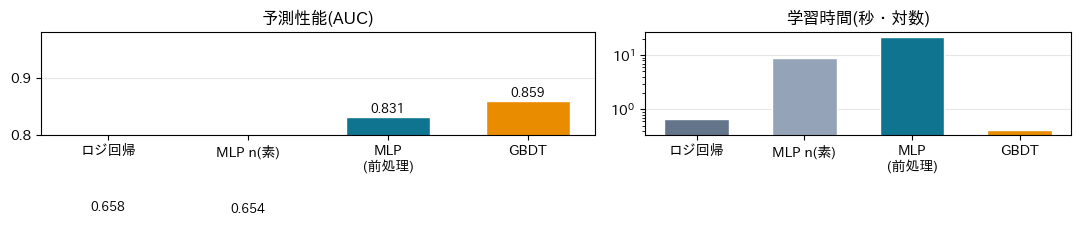

In [6]:
res = []
res.append(evaluate("ロジスティック回帰(第7回)", make_logreg()))
res.append(evaluate("MLP(スケーリングなし)", make_mlp_raw()))
res.append(evaluate("MLP(標準化+One-Hot)", make_mlp_ok()))
res.append(evaluate("勾配ブースティング (GBDT)", make_gbdt()))
labels = ["ロジ回帰", "MLP n(素)", "MLP\n(前処理)", "GBDT"]
colors = ["#64748B", "#94A3B8", "#0E7490", "#EA8C00"]
auc = [r["auc"] for r in res]; fit = [r["fit"] for r in res]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1.3,1]})
a1.bar(range (4), auc, 0.6, color=colors, edgecolor="white")
for i, u in enumerate (auc): a1.text(i, u+0.003, f"{u:.3f}", ha="center", va="bottom", fontsize =9)
a1.set_xticks (range (4)); a1.set_xticklabels (labels); a1.set_ylim(0.8, 0.98)
a1.set_title("予測性能(AUC)"); a1.grid(axis="y", alpha=.3); a1.set_axisbelow(True)
a2.bar(range(4), fit, 0.6, color=colors, edgecolor="white"); a2.set_yscale("log")
a2.set_xticks (range(4)); a2.set_xticklabels (labels); a2.set_title("学習時間(秒・対数)")
a2.grid(axis="y", alpha=.3); a2.set_axisbelow (True)
plt.tight_layout(); plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


 n=  500: MLP AUC=0.662 GBDT AUC=0.712


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


 n= 1000: MLP AUC=0.723 GBDT AUC=0.752


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


...

 n= 4000: MLP AUC=0.786 GBDT AUC=0.829


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


 n= 8000: MLP AUC=0.831 GBDT AUC=0.854


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


 n= 8291: MLP AUC=0.832 GBDT AUC=0.859


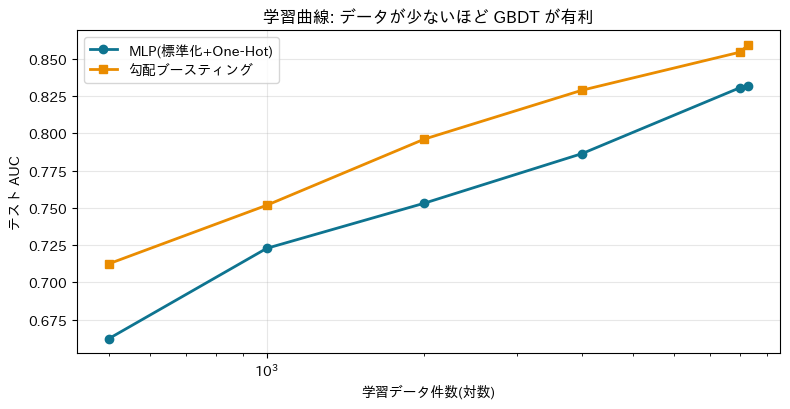

In [7]:
sizes = [500, 1000, 2000, 4000, 8000, len(Xtr)]
auc_mlp, auc_gb = [], []
for nsub in sizes:
    idx = RNG.choice (len(Xtr), size=min(nsub, len (Xtr)), replace=False)
    Xs, ys = Xtr.iloc[idx], ytr[idx]
    m = clone(make_mlp_ok()); m.fit(Xs, ys)
    g = clone(make_gbdt()); g.fit(Xs, ys)
    am = roc_auc_score(yte, m.predict_proba(Xte) [:, 1])
    ag = roc_auc_score (yte, g.predict_proba(Xte) [:, 1])
    auc_mlp.append(am); auc_gb.append(ag)
    print(f" n={nsub:>5}: MLP AUC={am:.3f} GBDT AUC={ag:.3f}")

plt.figure(figsize=(8, 4.2))
plt.plot(sizes, auc_mlp, "o-", color="#0E7490", lw=2, label="MLP(標準化+One-Hot)")
plt.plot(sizes, auc_gb, "s-", color="#EA8C00", lw=2, label="勾配ブースティング")
plt.xscale("log"); plt.xlabel("学習データ件数(対数)"); plt.ylabel("テスト AUC")
plt.title("学習曲線: データが少ないほど GBDT が有利"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


 隠れ層 (16,)                AUC=0.764 学習時間=29.80s


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


 隠れ層 (64,)                AUC=0.811 学習時間=14.68s


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


 隠れ層 (64, 32)             AUC=0.831 学習時間=21.24s
 隠れ層 (128, 64, 32)        AUC=0.836 学習時間=59.81s
 隠れ層 (256, 128, 64, 32)   AUC=0.844 学習時間=68.98s


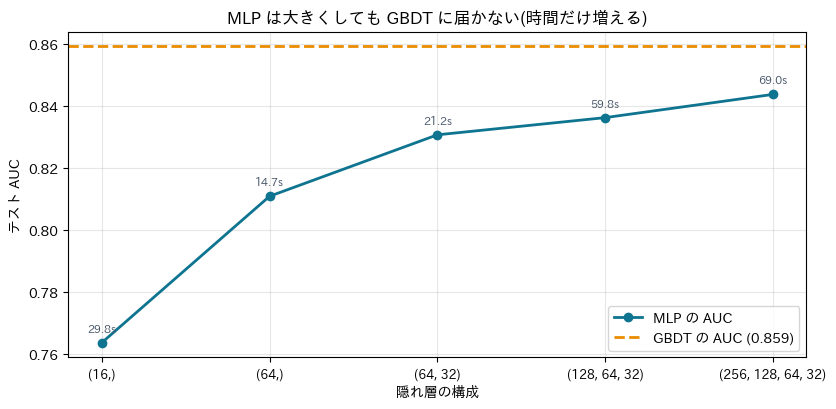

In [9]:
archs = [(16,), (64,), (64, 32), (128, 64, 32), (256, 128, 64, 32)]
auc_a, fit_a = [], []
for h in archs:
    m = make_mlp_ok(hidden=h, max_iter =300)
    t = time.time(); m.fit(Xtr, ytr); ft = time.time()-t
    a = roc_auc_score(yte, m.predict_proba(Xte) [:, 1])
    auc_a.append(a); fit_a.append(ft)
    print(f" 隠れ層 {str(h):20s} AUC={a:.3f} 学習時間={ft:5.2f}s")
gbdt_auc = res[3]["auc"]
fig, ax = plt.subplots(figsize =(8.5,4.2))
xs = range(len(archs))
ax.plot(xs, auc_a, "o-", color="#0E7490", lw=2, label="MLP の AUC")
ax.axhline(gbdt_auc, color="#EA8C00", ls="--", lw=2, label=f"GBDT の AUC ({gbdt_auc:.3f})")
for i, (a, f) in enumerate (zip(auc_a, fit_a)):
    ax.annotate(f"{f:.1f}s", (i, a), textcoords="offset points", xytext =(0,8), ha="center", fontsize =8, color="#475569")
ax.set_xticks(list(xs)); ax.set_xticklabels ([str(h) for h in archs], fontsize=9)
ax.set_xlabel("隠れ層の構成"); ax.set_ylabel("テスト AUC")
ax.set_title("MLP は大きくしても GBDT に届かない(時間だけ増える)")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

 calculated_host_listings_count   重要度=0.104
 neighbourhood                    重要度=0.083
 room_type                        重要度=0.077
 availability_365                 重要度=0.061
 longitude                        重要度=0.049
 latitude                         重要度=0.036
 minimum_nights                   重要度=0.022
 number_of_reviews                重要度=0.022
 reviews_per_month                重要度=0.017


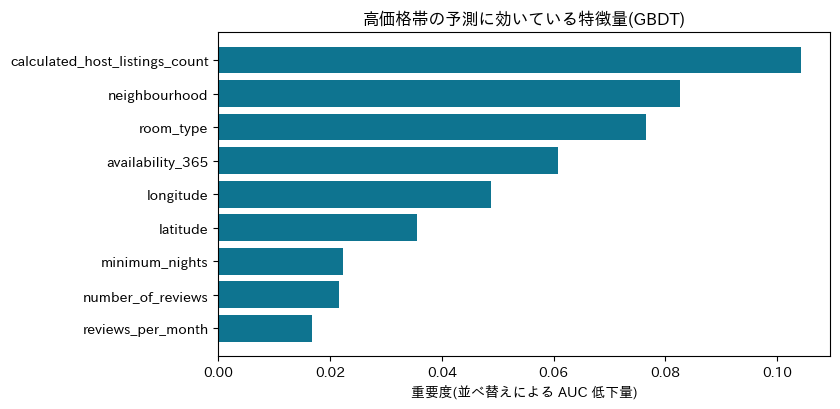

In [10]:
from sklearn.inspection import permutation_importance
gb = make_gbdt(); gb.fit(Xtr, ytr)
imp = permutation_importance (gb, Xte, yte, n_repeats =5, random_state=0, scoring="roc_auc")
order = np.argsort(imp.importances_mean)
feat_names = list(X.columns)
for i in order[::-1]:
    print(f" {feat_names[i]:32s} 重要度={imp.importances_mean[i]:.3f}")
plt.figure(figsize=(8.5, 4.2))
plt.barh([feat_names[i] for i in order], imp.importances_mean [order], color="#0E7490")
plt.xlabel("重要度(並べ替えによる AUC 低下量)")
plt.title("高価格帯の予測に効いている特徴量(GBDT)")
plt.tight_layout(); plt.show()